# Module 3 — Transformer Architecture


### Setup

*these will be present in the beginning of all the notebooks to make sure the environment is setup correctly in colab*

#### Setup Notebook Environment

### Installing Python libraries

**In Colab**, this might ask you to restart your session, do so and if you face issues that Gemini can't help you with ask the TA.

In [1]:
import pkg_resources
try:
    import google.colab
    IN_COLAB = True
    print("Running on Colab, let's run through the installs")
except ImportError:
    IN_COLAB = False
    print("Running locally, assuming you have a venv setup already done.")

def check_and_get_missing(requirements):
    to_install = []
    for pkg, ver in requirements.items():
        try:
            installed = pkg_resources.get_distribution(pkg).version
            if ver and installed != ver:
                print(f"Version mismatch for {pkg}: found {installed}, need {ver}")
                to_install.append(f"{pkg}=={ver}")
        except pkg_resources.DistributionNotFound:
            print(f"Package {pkg} not found.")
            to_install.append(f"{pkg}=={ver}" if ver else pkg)
    return to_install

if IN_COLAB:
    # 1. PYTORCH CHECK
    torch_reqs = {"torch": "2.2.0", "torchvision": "0.17.0", "torchaudio": "2.2.0"}
    missing_torch = check_and_get_missing(torch_reqs)
    if missing_torch:
        print("Uninstalling potentially conflicting torch packages...")
        !pip uninstall -y torch torchvision torchaudio
        print("Installing correct PyTorch versions...")
        !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu121

    # 2. CORE LIBRARIES CHECK
    core_reqs = {
        "chromadb": "0.5.5",
        "numpy": "1.26.4",
        "transformers": "5.5.4",
        "posthog": "2.5.0",
        "ollama": None
    }
    missing_core = check_and_get_missing(core_reqs)
    if missing_core:
        print(f"Installing/Updating: {missing_core}")
        !pip install -U {' '.join(missing_core)}

    # 3. UNSLOTH CHECK
    try:
        import unsloth
    except ImportError:
        print("Installing Unsloth...")
        !pip install --no-cache-dir unsloth

    import torch
    print("Final Check - Torch:", torch.__version__, "CUDA:", torch.version.cuda)

/tmp/ipykernel_14890/1512986679.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Running on Colab, let's run through the installs
Version mismatch for torch: found 2.2.0+cu121, need 2.2.0
Version mismatch for torchvision: found 0.17.0+cu121, need 0.17.0
Version mismatch for torchaudio: found 2.2.0+cu121, need 2.2.0
Uninstalling potentially conflicting torch packages...
Found existing installation: torch 2.2.0+cu121
Uninstalling torch-2.2.0+cu121:
  Successfully uninstalled torch-2.2.0+cu121
Found existing installation: torchvision 0.17.0+cu121
Uninstalling torchvision-0.17.0+cu121:
  Successfully uninstalled torchvision-0.17.0+cu121
Found existing installation: torchaudio 2.2.0+cu121
Uninstalling torchaudio-2.2.0+cu121:
  Successfully uninstalled torchaudio-2.2.0+cu121
Installing correct PyTorch versions...
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.2.0%2Bcu121-cp312-cp312-linux_x86_64.whl (757.2 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.17.0%2Bcu121-cp

Get Ollama — the inference engine we use to run the model locally

In [2]:
import subprocess
import os
import glob

def _is_already_installed(service_name: str) -> bool:
    result = subprocess.run(['which', service_name], capture_output=True)
    if result.returncode == 0:
        print(service_name, " already installed")
        return True
    return False

def find_course_dir_gdrive() -> str:
    matches = [
        os.path.dirname(m)
        for m in glob.glob('/content/drive/**/pyproject.toml', recursive=True)
        if 'applied-ml-course' in open(m).read()
    ]
    if not matches:
        return input("Please enter the correct path to 'student_scaffolding' folder in your Google Drive: ")
    return matches[0]


if IN_COLAB:
    !sudo apt-get install zstd
    if not _is_already_installed("ollama"):
        # Install Ollama
        !curl -fsSL https://ollama.com/install.sh | sh


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (5,405 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122412 files and directories currently

Getting the data and making sure we are in the right root directory.

There are two recommended ways,
- Upload to drive from your local using "setup assistant"
- Use github with PAT token

While we have tried to accommodate different styles of working there might still be exceptions and ways of doing this that we might have skipped to test.

**Getting the PAT from Github**

Documentation: https://dev.to/warnerbell/how-to-generate-a-github-personal-access-token-pat-1bg5

Options:
  - Choose Classic Token
  - Give access to repo

In [3]:
if IN_COLAB:
    import os
    import subprocess
    import zipfile
    import getpass

    # ----------------------------
    # CONFIG
    # ----------------------------
    REPO_URL = "https://github.com/Aggregate-Intellect/watspeed-llm-course-student-repo.git"
    TARGET_DIR = "/content/repo"

    # Optional: set to None or a branch name
    REPO_BRANCH = None  # or None for main

    # ----------------------------
    # MENU
    # ----------------------------
    print("""
    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    """)

    choice = input("Enter choice (1, 2, 3): ").strip()

    # ----------------------------
    # DRIVE (optional)
    # ----------------------------
    def try_drive():
        try:
            from google.colab import drive
            drive.mount('/content/drive')

            default_path = "/content/drive/MyDrive/watspeed_llm_course"
            if os.path.exists(default_path):
                print(f"📁 Default path found: {default_path}")
                return default_path

            print("🔄 Searching Google Drive...")

            path = find_course_dir_gdrive()  # optional external helper

            if path:
                print(f"📁 Drive found: {path}")
                return path

        except Exception as e:
            print("⚠️ Drive failed:", e)

        return None


    # ----------------------------
    # GIT (MAIN + BRANCH SUPPORT)
    # ----------------------------
    def try_git(repo_url, branch=None):
        try:
            if os.path.exists(TARGET_DIR):
                print("📁 Repo already exists, reusing...")
                return TARGET_DIR

            # default branch = main
            branch = branch or "main"

            print(f"🔄 Cloning repo (branch: {branch})...")

            def run_clone(url):
                return subprocess.run(
                    ["git", "clone", "--branch", branch, "--single-branch", url, TARGET_DIR],
                    text=True,
                    capture_output=True
                )

            # 1) try public clone
            result = run_clone(repo_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("⚠️ Public clone failed. Trying PAT...")

            # 2) PAT fallback
            token = getpass.getpass("🔐 Enter GitHub PAT: ")

            auth_url = repo_url.replace(
                "https://", f"https://{token}:x-oauth-basic@"
            )

            result = run_clone(auth_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("❌ Git clone failed")
            print(result.stderr)
            return None

        except Exception as e:
            print("⚠️ Git error:", e)
            return None


    # ----------------------------
    # ZIP IMPORT
    # ----------------------------
    def try_zip():
        print("📦 Upload ZIP...")
        from google.colab import files

        uploaded = files.upload()
        if not uploaded:
            print("⚠️ No file uploaded")
            return None

        zip_file = list(uploaded.keys())[0]

        try:
            with zipfile.ZipFile(zip_file, 'r') as z:
                z.extractall("/content")
        except zipfile.BadZipFile:
            print("❌ Invalid ZIP file")
            return None

        folder = zip_file.replace(".zip", "")
        path = os.path.join("/content", folder)

        print(f"📁 Extracted: {path}")
        return path


    # ----------------------------
    # MAIN LOGIC
    # ----------------------------
    project_path = None

    if choice == "2":
        project_path = try_git(REPO_URL, REPO_BRANCH)

    elif choice == "3":
        project_path = try_zip()

    else:
        # AUTO MODE
        project_path = try_drive()

        if not project_path:
            project_path = try_git(REPO_URL, REPO_BRANCH)

        if not project_path:
            project_path = try_zip()


    # ----------------------------
    # FINAL STEP
    # ----------------------------
    if project_path and os.path.exists(project_path):
        try:
            os.chdir(project_path)
            print("✅ Active directory:", os.getcwd())
            print("📂 Contents:", os.listdir())
        except Exception as e:
            print("❌ Failed to switch directory:", e)
    else:
        print("❌ No project loaded")

else:
    def in_root_folder() -> bool:
        return os.path.isdir("notebooks") and os.path.isdir("data")

    if not in_root_folder():
        import os
        os.chdir("..")


    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    
Enter choice (1, 2, 3): 2
🔄 Cloning repo (branch: fix/technical-issues-review)...
⚠️ Public clone failed. Trying PAT...
🔐 Enter GitHub PAT: ··········
✅ Active directory: /content/repo
📂 Contents: ['CLAUDE.md', 'README.md', '.git', 'src', 'notebook_image_catalogue.md', 'uv.lock', 'notebooks', 'upload_to_colab.sh', '.claude', 'pyproject.toml', '.gitignore', 'technical_issues.md', 'prompts', 'course_setup.md', 'data', 'project_structure.md', '.python-version']


In [4]:
from IPython.display import display, Markdown

#### Start Ollama and Load the model

In [13]:
if IN_COLAB:
    import subprocess, time
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(3)  # give it a moment to start

!ollama pull gemma2:2b
!ollama pull nomic-embed-text

In [14]:
import ollama

ollama.generate(
    model="gemma2:2b",
    prompt="hi, who is out there?"
).response

"Hello! 👋  It seems like you're reaching out to the digital world. I am Gemma, an AI assistant here to help with any questions or tasks you may have. What can I do for you today? 😊 \n"

---

---

## Transformers and embeddings


So far we have covered tokens and embeddings — vectors that place similar recipes near each other in high-dimensional space. This section covers how these embeddings are used by transformers to generate text.

A transformer receives the embeddings and runs each token's embedding through a process called **attention**. At each step, attention decides which other tokens to focus on in the context. This is how `"marinated chicken"` can pick up the signal from `"overnight"` three words later — even though the words aren't adjacent, attention lets the model reach across the gap and make these connections using the embedding space.

> **Side note:** Attention also gives us a nice improvement over classical encoding methods, which required fixed-length representations. With attention, there is no architectural hard limit on text length — though practical limits come from the quadratic cost of attention and the context length the model was trained on (covered below) — which is why attention-based architectures now dominate NLP.

But attention doesn't just happen once. Transformers run *multiple* attention passes in parallel called **multi-head attention** each one during training has learned to focus on different kinds of relationships. One head might learn to link ingredients to their quantities (`"2 cups"` → `"flour"`), another might connect cooking verbs to their objects (`"marinate"` → `"chicken"`), and another might track temporal signals (`"overnight"`, `"30 minutes"`, `"until golden"`).

After attention, each token's embedding passes through a **feed-forward network**. Given the full combination of context signals, this layer resolves ambiguity: `"light"` in `"light seasoning"` gets treated very differently from `"light"` in `"light the grill"`. The feed-forward step is where that disambiguation gets baked in.

This pairing of **attention + feed-forward** is the core building block of a transformer. And as we'll see next, it is stacked many times — each layer refining the representation further.

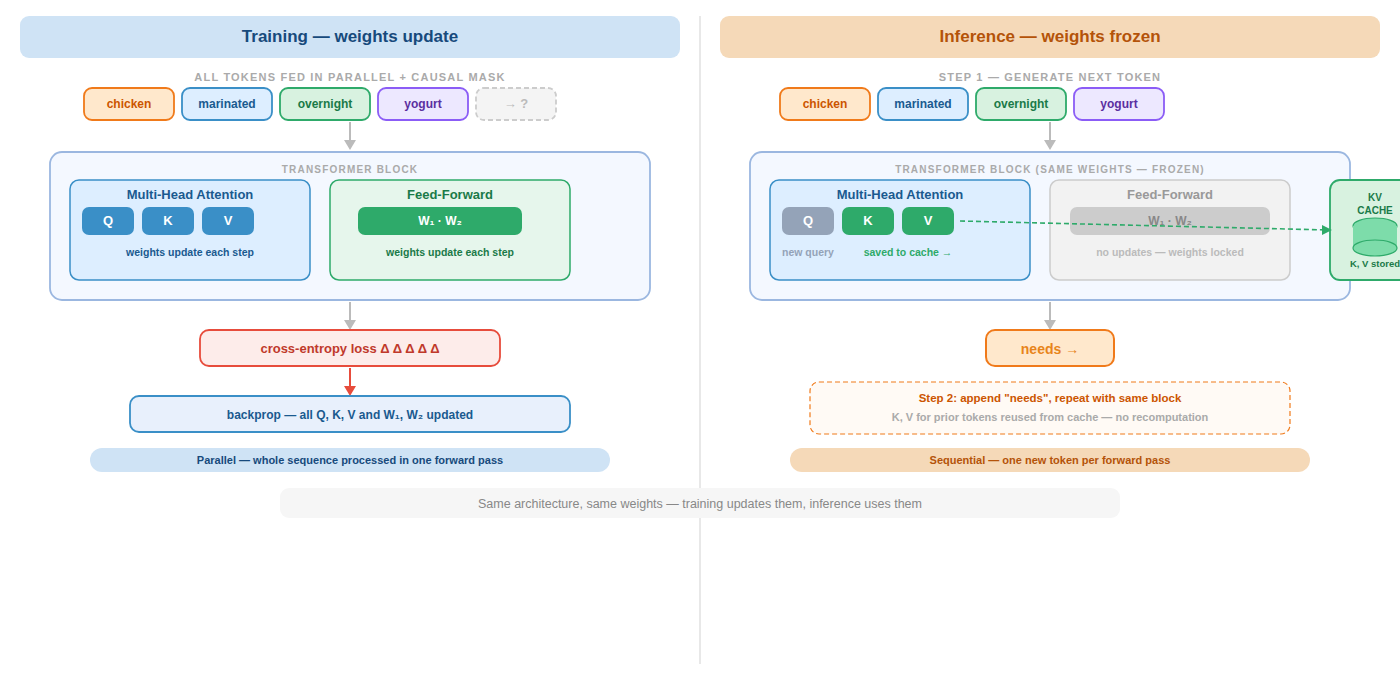

*Supplementary reads*
- [Transformer Explainer](https://poloclub.github.io/transformer-explainer/) — visual, interactive
- [Deep dive into self-attention by hand](https://towardsdatascience.com/deep-dive-into-self-attention-by-hand-%EF%B8%8E-f02876e49857/) — worked example

### Causal Masking (why LLMs type a single word at a time)

When we watch an LLM respond, it generates one token at a time, left to right, never skipping ahead. That is exactly how the model works.

A transformer *could* attend to all tokens in both directions at once — and some models do (BERT is the classic example). Bidirectional attention works well for understanding text, but not for generation. During training, models like Gemma are never allowed to peek at future tokens when learning to predict the current one and this behavior is enforced by **Causal masking**.

It literally just hides the upper triangle of the attention matrix so that each token can only attend to positions at or before its own position.


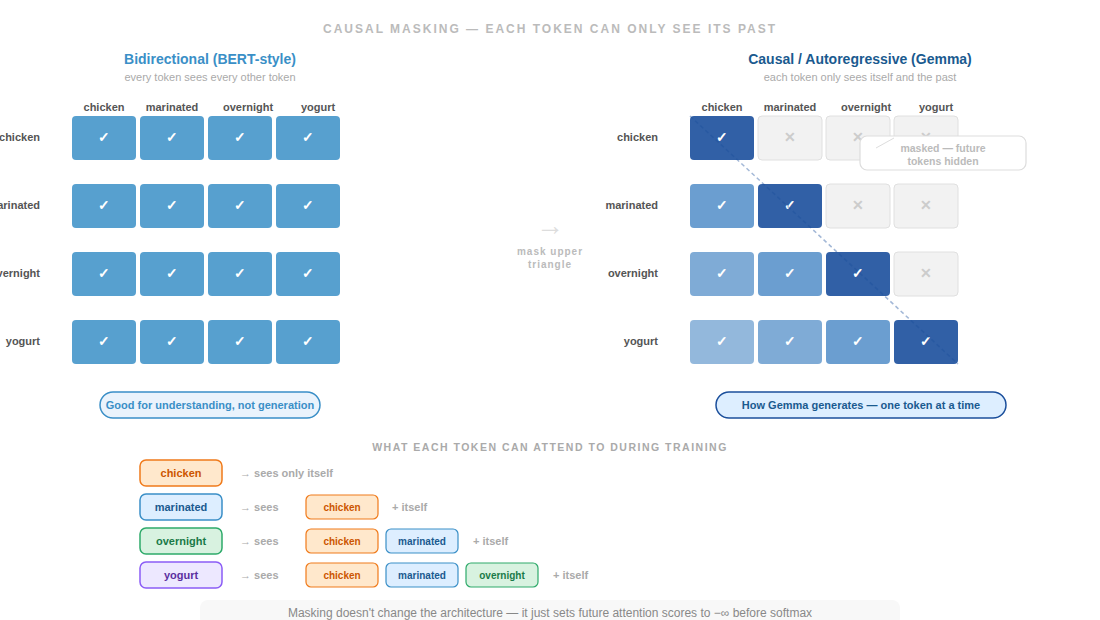

The practical consequence is that these two model families end up being quite different:

| | BERT | GPT / Gemma |
|---|---|---|
| **Attention direction** | Bidirectional — sees full context | Causal — left-to-right only |
| **Training objective** | Predict a masked token from surrounding context | Predict the *next* token |
| **Good for** | Classification, understanding | Generation |

When prompting `gemma2:2b`, the left-to-right generation is a fundamental property of how causal models are trained — they are built to *continue*, not to complete.

### The Cost of Generating One Token

Since these models are generating token by token, every time the model produces a new token, it runs a full attention pass over all the tokens before it.

That means if our prompt is 200 tokens long and Gemma is generating a 100-token response, by the end it is running attention over ~300 tokens — and that full forward pass runs through all 26 layers (one per layer) and with larger models even more.

The compute cost grows quickly:

| | Attention | Feed-Forward |
|---|---|---|
| Scales with sequence length | **Quadratically** (n²) | Linearly (n) |
| Scales with model dimension | Linearly (d) | Quadratically (d²) |

For short prompts (a recipe name, a few sentences), the FFN dominates. Once our context gets long, attention takes over.

**The KV cache**

When generating token by token: the K and V matrices for all past tokens don't change. Rather than recomputing them from scratch on every step, the model caches them. Per layer, that cache holds:

```
KV cache per layer = 2 × n_kv_heads × d_k × n_tokens × 2 bytes
```
The cell below computes the **total** KV cache across all layers (per-layer × N_LAYERS) and the attention cost at peak context length.

In [15]:
# Gemma 2B architecture constants
N_LAYERS     = 26
N_Q_HEADS    = 8
N_KV_HEADS_MHA = 8   # standard multi-head attention
N_KV_HEADS_GQA = 4   # what Gemma 2 actually uses
D_K          = 256   # head dimension = 2048 / 8
BYTES        = 2     # float16


def compute_transformer_cost(prompt_text: str, response_tokens: int = 100):
    """Estimate attention compute and KV cache cost for a given prompt."""

    # Rough token estimate: ~4 characters per token for English text
    n_prompt  = max(1, len(prompt_text) // 4)
    n_total   = n_prompt + response_tokens

    # Attention matrix: n² scores per head per layer (at peak — end of response)
    attn_scores = n_total ** 2 * N_Q_HEADS * N_LAYERS

    # KV cache at end of response (MHA vs GQA)
    def kv_cache_mb(n_kv_heads):
        return (2 * n_kv_heads * D_K * n_total * N_LAYERS * BYTES) / 1e6

    kv_mha = kv_cache_mb(N_KV_HEADS_MHA)

    print(f"Prompt:          ~{n_prompt:,} tokens  ({len(prompt_text):,} chars)")
    print(f"Response budget: {response_tokens} tokens")
    print(f"Total context:   {n_total:,} tokens at peak")
    print()
    print(f"Attention scores per forward pass: {attn_scores:,.0f}")
    print(f"  = {n_total}² × {N_Q_HEADS} heads × {N_LAYERS} layers")
    print()
    kv_gqa = kv_cache_mb(N_KV_HEADS_GQA)

    print(f"KV cache (standard MHA, {N_KV_HEADS_MHA} KV heads): {kv_mha:.1f} MB")
    print(f"KV cache (GQA,          {N_KV_HEADS_GQA} KV heads): {kv_gqa:.1f} MB  ← {kv_gqa/kv_mha:.0%} of MHA")

compute_transformer_cost("Choose a recipe for me")

Prompt:          ~5 tokens  (22 chars)
Response budget: 100 tokens
Total context:   105 tokens at peak

Attention scores per forward pass: 2,293,200
  = 105² × 8 heads × 26 layers

KV cache (standard MHA, 8 KV heads): 22.4 MB
KV cache (GQA,          4 KV heads): 11.2 MB  ← 50% of MHA


**Exercise — how expensive is our prompt?**

Use the prompt we wrote in the first week below to see the cost of it.

In [16]:
my_prompt = """ You are a recipe time classifier. Given a dish name and optional context, predict which time category it belongs to.

  Categories:
  A: Quick, No-Wait - Total time ≤ 30 min, no wait time
  B: Medium, No-Wait - 30 < total time ≤ 60 min, no wait time
  C: Long, No-Wait - Total time > 60 min, no wait time
  D: Short Wait - Wait time 1-30 min (rest, marinate, chill)
  E: Long Wait - Wait time > 30 min (overnight marinate, long chill)

  Instructions:
  - Analyze the dish information provided
  - Consider typical preparation requirements
  - Respond with ONLY the category letter (A, B, C, D, or E)
  - Do not include explanation

  Input: Dish: Chicken Souvlaki, Servings: 4, Ingredient count: 12, Description: A classic Greek grilled chicken...

  Category:

  The Input: line varies — if the dish isn't found in the dataset, it's just Dish: Chicken Souvlaki with no context."""  # ← paste your classifier prompt

compute_transformer_cost(my_prompt)

Prompt:          ~220 tokens  (880 chars)
Response budget: 100 tokens
Total context:   320 tokens at peak

Attention scores per forward pass: 21,299,200
  = 320² × 8 heads × 26 layers

KV cache (standard MHA, 8 KV heads): 68.2 MB
KV cache (GQA,          4 KV heads): 34.1 MB  ← 50% of MHA


**Note:** In a conversational interface that includes tools and MCPs, this cost grows even faster — which is why *context engineering* has emerged as a distinct concern, and why model providers continue to extend context window sizes.

### Grouped Query Attention (GQA) & Quantization — The Optimizations

There are engineering optimizations that allow capable models to run on consumer GPUs and edge devices.

**Grouped Query Attention**:


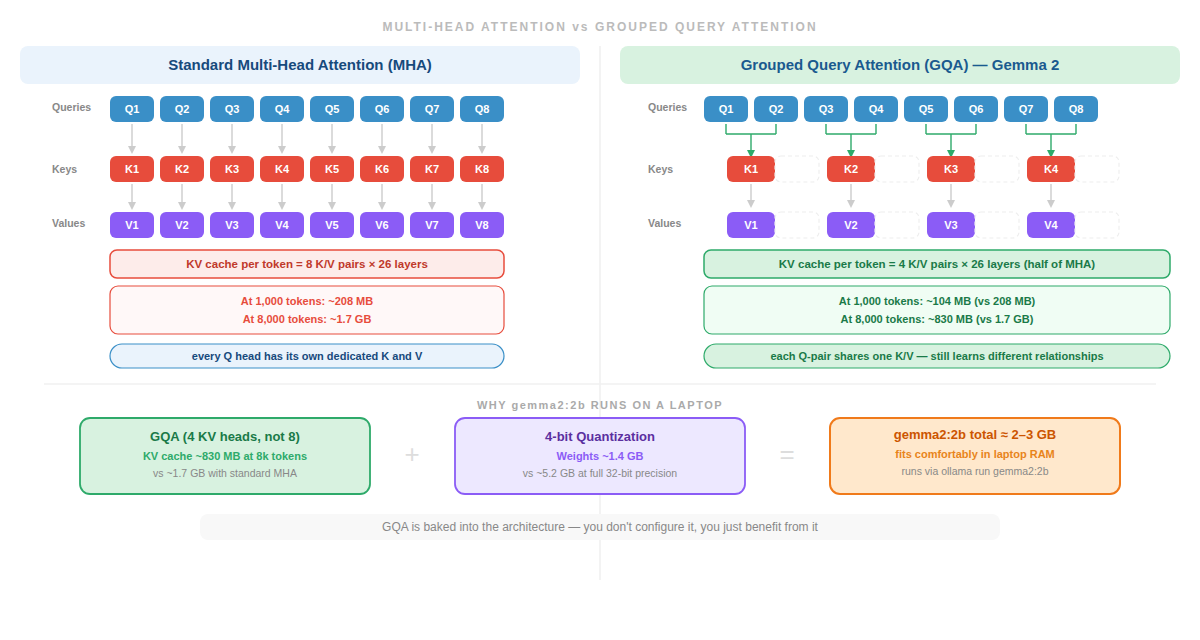


Pairs of query heads share one K/V projection. The KV cache is halved compared to MHA, while each pair of heads still specializes in different relationship types.

Combined with 4-bit quantization of the weights (~1.4 GB instead of 5.2 GB), `gemma2:2b` fits comfortably in 2–3 GB total — which is why it runs on a laptop CPU.

> GQA is an engineering choice baked into the model architecture. It does not require implementation — it is an architecture choice that benefits every `ollama run gemma2:2b` call.

**This is why context window length matters so much:** computation scales quadratically with sequence length (O(n²) attention scores). Doubling our prompt length quadruples the attention computation.

---

## Context Management


Compute is expensive and context windows are finite. Rather than relying on ever-larger contexts, a better approach is to be selective about what goes in — retrieving only the most relevant information for each request. Let's look at how to do that with the recipe dataset.


Consider a query: picking the top recipe given only cooking time and ingredients.

In [17]:
import pandas as pd

recipes = pd.read_csv("data/All_Recipe_Web_Scraping_Dataset_Labeled.csv")

recipe_count = recipes.Description.count()
avg_recipe_words = recipes.Description.apply(lambda x: len(x.split())).mean()

print(f"There are {recipe_count} recipes with avg description")
print(f"{avg_recipe_words} .i.e. my prompt even without any actual prompt")
print("------")
compute_transformer_cost("lorem ipsum" * (recipe_count * int(avg_recipe_words)))

print("With GQA approx half of this")

There are 13057 recipes with avg description
33.40376809374282 .i.e. my prompt even without any actual prompt
------
Prompt:          ~1,184,922 tokens  (4,739,691 chars)
Response budget: 100 tokens
Total context:   1,185,022 tokens at peak

Attention scores per forward pass: 292,089,645,220,672
  = 1185022² × 8 heads × 26 layers

KV cache (standard MHA, 8 KV heads): 252400.2 MB
KV cache (GQA,          4 KV heads): 126200.1 MB  ← 50% of MHA
With GQA approx half of this


The token count exceeds Gemma 2B's 8,192-token context window.

These context explosions are a great opportunity for vector stores *(covered in more depth in Module 6)* , i.e., a database that can store all the recipe descriptions in vector form.

**Why vectors?** When we embed a recipe as a vector, similar recipes end up close together in that high-dimensional space. A slow-braised stew lands near other slow-cook recipes; a quick stir-fry lands near other fast dishes. Instead of scanning all recipes or picking randomly, we embed the query recipe and retrieve only the k nearest neighbors — the most semantically similar labeled examples.

This is where the dedicated embedding models from the previous module become useful. Let's set up the vector store.

### Setting Up the Vector Store *(covered in more depth in Module 6)*

We will use ChromaDB for simplicity — it is an in-memory datastore with an option to persist via a SQLite database containing the embeddings.

In [18]:
import chromadb

client = chromadb.PersistentClient(path="./chroma_store")
collection = client.get_or_create_collection("recipes")
print(f"Collection 'recipes' has {collection.count()} documents.")

Collection 'recipes' has 0 documents.


Now we embed each recipe description and push it into the collection. We use `nomic-embed-text`, a dedicated embedding model — as Module 2 explained, dedicated embedding models produce better semantic similarity vectors than generative models like `gemma2:2b`. We store the label and name as metadata so we can inspect what comes back at query time.

In [19]:
import ollama

BATCH_SIZE = 100
MAX_BATCHES = 2  # Set to an integer to limit batches processed (e.g. 5); None = process all

existing_ids = set(collection.get()["ids"])
to_add = recipes[~recipes.index.astype(str).isin(existing_ids)]
to_add = to_add[to_add["Description"].astype(str).str.strip() != ""]
print(f"Adding {len(to_add)} new recipes (skipping {len(recipes) - len(to_add)} already stored)...")

rows = [
    (str(idx), str(row["Description"]), str(row.get("Prep Time", "")), str(row.get("Name", "")))
    for idx, row in to_add.iterrows()
]

for batch_num, i in enumerate(range(0, len(rows), BATCH_SIZE)):
    if MAX_BATCHES is not None and batch_num >= MAX_BATCHES:
        print(f"Stopped after {MAX_BATCHES} batches ({batch_num * BATCH_SIZE} recipes).")
        break

    batch = rows[i:i + BATCH_SIZE]
    ids       = [r[0] for r in batch]
    texts     = [r[1] for r in batch]
    prep_time = [r[2] for r in batch]
    names     = [r[3] for r in batch]

    embeddings = ollama.embed(model="nomic-embed-text", input=texts)["embeddings"]

    collection.add(
        ids=ids,
        embeddings=embeddings,
        documents=texts,
        metadatas=[{"prep_time": p, "name": n} for p, n in zip(prep_time, names)],
    )
    print(f"  {min(i + BATCH_SIZE, len(rows))}/{len(rows)} done")

print(f"Done. Collection now has {collection.count()} documents.")

Adding 13057 new recipes (skipping 0 already stored)...
  100/13057 done
  200/13057 done
Stopped after 2 batches (200 recipes).
Done. Collection now has 200 documents.


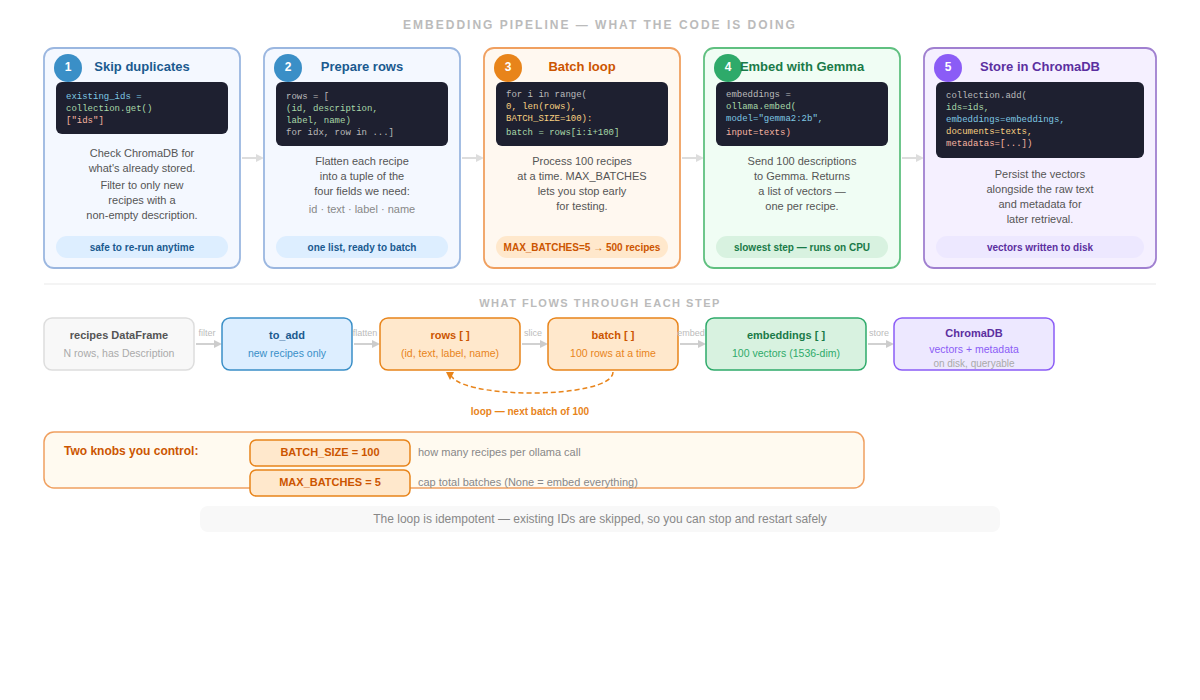

With the vector store *(covered in more depth in Module 6)* populated, we can now query it. We embed a test recipe description and ask ChromaDB for the 3 most similar stored recipes.

In [20]:
test_query = "I would love to make chicken quickly"
q_embedding = ollama.embed(model="nomic-embed-text", input=test_query)["embeddings"][0]
results = collection.query(
    query_embeddings=[q_embedding],
    n_results=3,
    include=["documents", "metadatas", "distances"]
)

print(f"Query: '{test_query}'\n")
for i, (doc, meta, dist) in enumerate(zip(
    results["documents"][0],
    results["metadatas"][0],
    results["distances"][0],
)):
    print(f"[{i+1}] {meta['name']}  (prep_time={meta['prep_time']}, distance={dist:.4f})")
    print(f"     {doc[:100]}...")
    print()

Query: 'I would love to make chicken quickly'

[1] Easy Steam Chicken  (prep_time=15 mins, distance=0.5824)
     This steamed chicken is delicious and popular in Southeast Asian countries, where it's typically ser...

[2] Jamaican Jerk Chicken  (prep_time=20 mins, distance=0.6033)
     This jerk chicken recipe is a succulent, tropical treat. You'll love the heat and flavor of this fie...

[3] Air Fryer Buffalo Chicken Wings from Frozen  (prep_time=5 mins, distance=0.6222)
     Forget to thaw those wings and in a pinch? No problem. Here is my how-to cook chicken wings from fro...



---

### What if embedding is not enough

The results above are a great example of a situation where embedding is not enough and we can improve this by either finding a better embedding model (which we covered the previous module) or we can solve it by improving our embedding and querying pipeline.

The main problem that we see in our example above is the ingredients are completely ignored by the embedding and the raw description embedding clusters "vegan black bean" and "chicken" close to each other *maybe* because they are good sources of proteins.

We can improve the *embedding process*, the *querying process*, or both. Improving the querying process means extracting relevant information — such as ingredients — from the user query and adding that as a filter.

In [29]:
import json

def extract_query_intent(user_query: str) -> dict:
    """Use ollama to pull structured preferences from a natural language query.

    Returns a dict with keys:
      - ingredient: main ingredient mentioned, or None
      - time_preference: "quick" | "medium" | "long" | None
    """
    prompt = f"""Extract the user's recipe preferences from this query as JSON.
Return only valid JSON with these exact keys (use null if not mentioned):
- "ingredient": the main ingredient they want (string or null)

Query: "{user_query}"
JSON:"""

    response = ollama.chat(
        model="gemma2:2b",
        messages=[{"role": "user", "content": prompt}],
        format="json",
    )
    return json.loads(response["message"]["content"])


# Demo — same query that gave us bad results before
test_query = "I would love to make chicken quickly"
intent = extract_query_intent(test_query)
print(f"Query:  {test_query!r}")
print(f"Intent: {intent}")
# Expected → {"ingredient": "chicken" }

Query:  'I would love to make chicken quickly'
Intent: {'ingredient': 'chicken'}


In [30]:
ingredient = intent.get("ingredient")
if not ingredient:
    print("No ingredient detected in query — falling back to embedding-only search.")
    results = collection.query(
        query_embeddings=[q_embedding],
        n_results=3,
        include=["documents", "metadatas", "distances"],
    )
else:
    results = collection.query(
        query_embeddings=[q_embedding],
        n_results=3,
        include=["documents", "metadatas", "distances"],
        where_document={"$contains": ingredient}
    )

print(f"Query: '{test_query}'\n")
for i, (doc, meta, dist) in enumerate(zip(
    results["documents"][0],
    results["metadatas"][0],
    results["distances"][0],
)):
    print(f"[{i+1}] {meta['name']}  (prep_time={meta['prep_time']}, distance={dist:.4f})")
    print(f"     {doc[:100]}...")
    print()

Query: 'I would love to make chicken quickly'

[1] Easy Steam Chicken  (prep_time=15 mins, distance=0.5824)
     This steamed chicken is delicious and popular in Southeast Asian countries, where it's typically ser...

[2] Jamaican Jerk Chicken  (prep_time=20 mins, distance=0.6033)
     This jerk chicken recipe is a succulent, tropical treat. You'll love the heat and flavor of this fie...

[3] Air Fryer Buffalo Chicken Wings from Frozen  (prep_time=5 mins, distance=0.6222)
     Forget to thaw those wings and in a pinch? No problem. Here is my how-to cook chicken wings from fro...



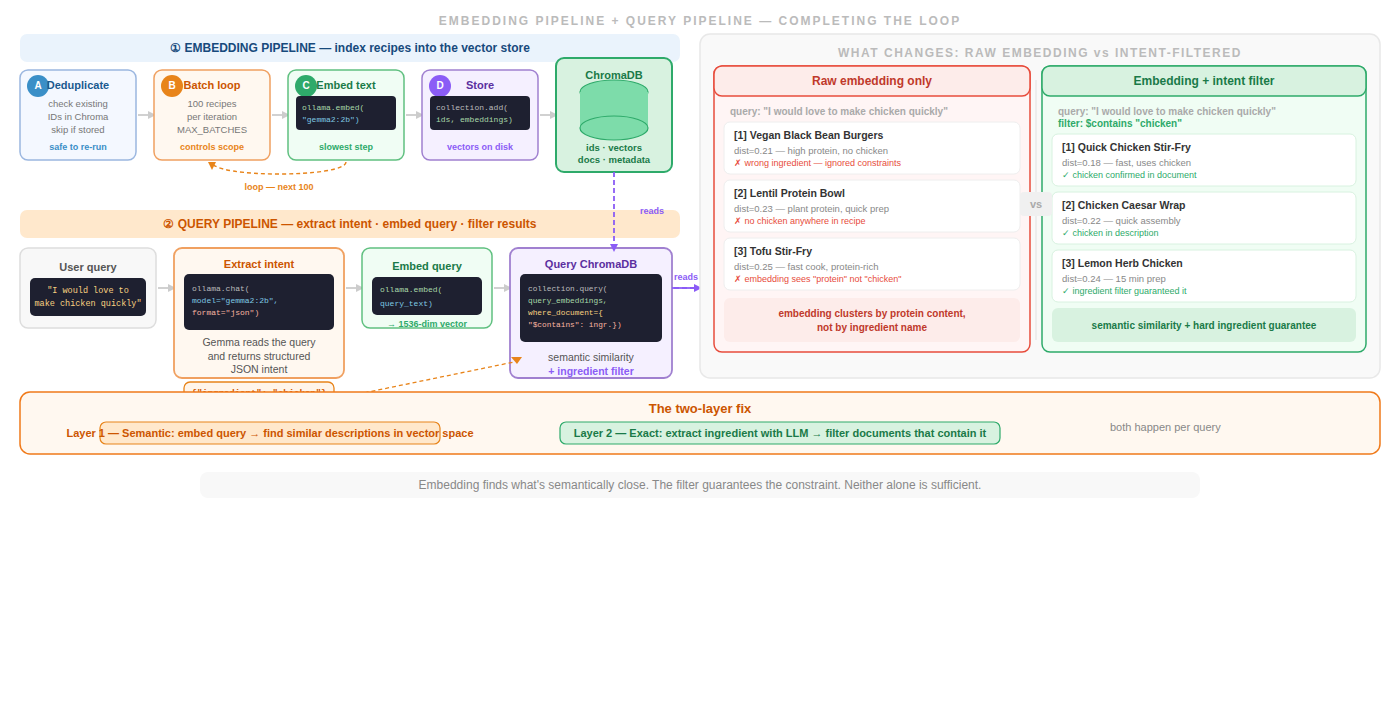

---
## More ways to handle context

LLM engineering is a rapidly evolving research area, with new techniques emerging regularly.

### Extending the Context Window

- **RoPE scaling (YaRN, LongRoPE)**: Rescale the rotary position encodings to extrapolate beyond the training context length. Gemma 2B uses RoPE (which we saw in Module 2), and these methods extend it without retraining from scratch.
- **Sliding window attention (Longformer, Mistral)**: Each token attends only to a local window of nearby tokens plus a few global tokens. Reduces attention from O(n²) to O(n·w) where w is the window size.
- **Flash Attention**: A memory-efficient GPU kernel that computes attention in tiles, avoiding materializing the full n×n matrix. Doesn't change what the model computes — just makes it faster and cheaper.
- **Very long context models (Gemini 1.5, Claude)**: Claim 1M+ tokens using architectural innovations and large-scale training. Still subject to a well-documented "lost in the middle" effect — models struggle to use information from the middle of very long contexts.



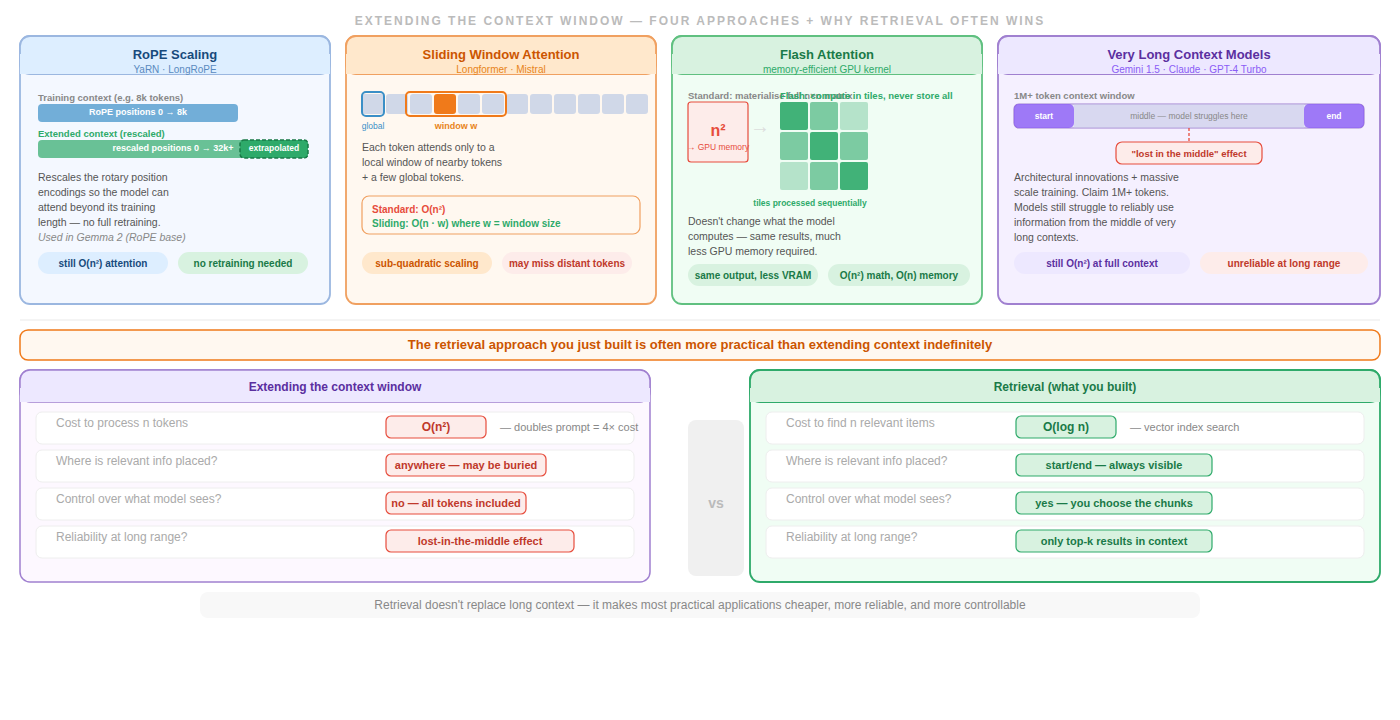

### Training Methods: A Preview

Now that you understand how the transformer is structured, here is the landscape of methods practitioners use to adapt it — we will cover several of these in detail in Modules 5 and 6.
Some use cases require optimizing what the model *generates*, not just what it knows. Examples include producing diagrams with no overlaps, generating infographics using specific layout tools, or predicting tokens in a new language.

#### Techniques

- **Continued Pretraining**: Resume training on domain-specific unlabeled text (e.g. medical records, code, a new language) to shift the model's token distribution without changing its architecture. The model learns new vocabulary patterns and facts, but no labels are needed — the loss is still next-token prediction.

- **Supervised Fine-Tuning (SFT)**: Train on labeled `(prompt, completion)` pairs to teach the model a specific input→output behavior — e.g. always returning valid JSON, following a diagram layout schema, or responding in a new language. This is the most common first step after continued pretraining.

- **Reinforcement Learning from Human Feedback (RLHF)**: A separate reward model is trained on human preference rankings, then the LLM is optimized against it using PPO. Used to align formatting, tone, safety, or tool-use conventions when the desired behavior is hard to express as labeled examples.

- **Preference Optimization without a Reward Model (DPO / ORPO)**: Direct Preference Optimization (DPO) and Odds-Ratio Preference Optimization (ORPO) skip the reward model and fine-tune directly on `(chosen, rejected)` output pairs. Cheaper to run than RLHF and often competitive in quality.

- **Parameter-Efficient Fine-Tuning — LoRA / QLoRA**: Instead of updating all weights, low-rank adapter matrices are injected into the attention layers. Only the adapters (≈1–2 % of parameters) are trained. QLoRA adds 4-bit quantization of the frozen base model so the whole process fits on a single consumer GPU.

- **Prompt Tuning / Prefix Tuning**: Learn a small set of soft token embeddings that are prepended to every input. The base model weights are fully frozen — only the prefix is trained. Useful when we need multiple task-specific variants of the same base model with minimal storage overhead.


We will cover this topic in more detail in the coming weeks.

---

## Key Takeaways

Transformers are the engine underneath every modern LLM. Understanding how they work tells you where the costs come from and why context management matters:

- **Attention captures long-range relationships.** Each token can attend to every other token in the context — this is how `"marinated overnight"` connects to `"chicken"` three words away, and why transformers outperform earlier sequence models on complex language tasks.
- **Causal masking enforces left-to-right generation.** The model is trained never to look at future tokens, which is why LLMs generate text one token at a time in sequence.
- **Compute scales quadratically with context length.** Doubling our prompt roughly quadruples attention cost. This is the practical reason context management and vector retrieval matter — keeping prompts short and relevant is not just good practice, it is necessary at scale.
- **Vector retrieval lets you be selective.** Instead of passing an entire dataset to the model, a vector store *(covered in more depth in Module 6)* returns only the most semantically relevant examples. This is the foundation of retrieval-augmented generation (RAG), which we will build on in later weeks.


**Your assignment:**

1. Estimate the context size your problem statement requires — how many tokens does a typical input take?
2. Create `retrieval/vector_store.py` with `add()` and `query()` methods using ChromaDB
3. Update `main.py` so the pipeline runs: embed query → retrieve → build prompt → classify